<a href="https://colab.research.google.com/github/thedatasense/robust-med-mllm-experiments/blob/main/03_Building_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building LLM from Scratch

This part is heavily inspired based on the work by Sebastian Raschka <br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>


In [ ]:
#tiktoken is a crucial tool used to handle tokenization in LLMs. It's a fast Byte Pair Encoding (BPE) tokenizer.
#Tokenization: Tokenization is like breaking down a sentence into individual words or sub-words, which LLMs understand.
#Think of it like chopping up ingredients before you start cooking.
#BPE (Byte Pair Encoding): It's the specific method tiktoken uses to break down text.
!pip install tiktoken

In [ ]:
from importlib.metadata import version
import os
import urllib.request
import importlib
import tiktoken
import torch
import pandas as pd
from torch.utils.data import DataLoader
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

torch version: 2.6.0+cu124
tiktoken version: 0.9.0


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
    #torch.cuda.set_device(1)  # Set GPU 1 as the active device
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using {device} device.")

Using cuda device.


### Dataset

The dataset is from MEDIQA-Chat @ [ClinicalNLP 2023]([https://sites.google.com/view/mediqa2023/clinicalnlp-mediqa-chat-2023])

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/wyim/aci-bench/refs/heads/main/data/challenge_data/train.csv")
df.head()

,dataset,encounter_id,dialogue,note
0,virtassist,D2N001,"[doctor] hi , martha . how are you ?\n[patient...",CHIEF COMPLAINT\n\nAnnual exam.\n\nHISTORY OF ...
1,virtassist,D2N002,"[doctor] hi , andrew , how are you ?\n[patient...",CHIEF COMPLAINT\n\nJoint pain.\n\nHISTORY OF P...
2,virtassist,D2N003,"[doctor] hi , john . how are you ?\n[patient] ...",CHIEF COMPLAINT\n\nBack pain.\n\nHISTORY OF PR...
3,virtassist,D2N004,"[doctor] hi , james , how are you ?\n[patient]...",CHIEF COMPLAINT\n\nBack pain.\n\nHISTORY OF PR...
4,virtassist,D2N005,"[doctor] hey , ms. hill . nice to see you .\n[...",CC:\n\nRight middle finger pain.\n\nHPI:\n\nMs...


In [ ]:
df

,dataset,encounter_id,dialogue,note
0,virtassist,D2N001,"[doctor] hi , martha . how are you ?\n[patient...",CHIEF COMPLAINT\n\nAnnual exam.\n\nHISTORY OF ...
1,virtassist,D2N002,"[doctor] hi , andrew , how are you ?\n[patient...",CHIEF COMPLAINT\n\nJoint pain.\n\nHISTORY OF P...
2,virtassist,D2N003,"[doctor] hi , john . how are you ?\n[patient] ...",CHIEF COMPLAINT\n\nBack pain.\n\nHISTORY OF PR...
3,virtassist,D2N004,"[doctor] hi , james , how are you ?\n[patient]...",CHIEF COMPLAINT\n\nBack pain.\n\nHISTORY OF PR...
4,virtassist,D2N005,"[doctor] hey , ms. hill . nice to see you .\n[...",CC:\n\nRight middle finger pain.\n\nHPI:\n\nMs...
...,...,...,...,...
62,aci,D2N063,[doctor] so gloria is a 46 -year-old female to...,CHIEF COMPLAINT\n\nDyspnea.\n\nMEDICAL HISTORY...
63,aci,D2N064,[doctor] hey matthew how're you doing\n[patien...,CHIEF COMPLAINT\n\nLeft ankle pain.\n\nHISTORY...
64,aci,D2N065,[doctor] hey anna good to see you today so i'm...,CHIEF COMPLAINT\n\nRight ankle pain.\n\nHISTOR...
65,aci,D2N066,[doctor] hey gabriel i'm doctor scott good to ...,CHIEF COMPLAINT\n\nBack pain evaluation.\n\nME...


In [ ]:
max_len = df['note'].str.len().max()
min_len = df['note'].str.len().min()

print(f"Maximum length of text in 'note' column: {max_len}")
print(f"Minimum length of text in 'note' column: {min_len}")


Maximum length of text in 'note' column: 5712
Minimum length of text in 'note' column: 852


In [ ]:
medical_abstracts = df['note'].astype(str).tolist()  # Extract the column and convert to a list of strings
text_data = ' '.join(medical_abstracts)  # Combine all abstracts into a single string
# Display the total number of characters and a preview of the combined text
print("Total number of characters:", len(text_data))
print(text_data[:700])

Total number of characters: 177568
CHIEF COMPLAINT

Annual exam.

HISTORY OF PRESENT ILLNESS

Martha Collins is a 50-year-old female with a past medical history significant for congestive heart failure, depression, and hypertension who presents for her annual exam. It has been a year since I last saw the patient.

The patient has been traveling a lot recently since things have gotten a bit better. She reports that she got her COVID-19 vaccine so she feels safer about traveling. She has been doing a lot of hiking.

She reports that she is staying active. She has continued watching her diet and she is doing well with that. The patient states that she is avoiding salty foods that she likes to eat. She has continued utilizing her


### GPT-2 Tokenization: Byte-Pair Encoding ###

- GPT-2 used Byte-Pair Encoding  as its tokenizer.
- It allows the model to break down words that aren't in its predefined vocabulary into smaller subword units or even individual characters, enabling it to handle out-of-vocabulary words.
- For instance, if GPT-2’s vocabulary doesn’t have the word *"unfamiliarword"*, it might tokenize it as `["unfam", "iliar", "word"]` or some other subword breakdown, depending on its trained BPE merges.
- The original BPE tokenizer can be found here: [https://github.com/openai/gpt-2/blob/master/src/encoder.py](https://github.com/openai/gpt-2/blob/master/src/encoder.py)


In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")
enc_text = tokenizer.encode(text_data)
print("Total number of character:", len(enc_text))

Total number of character: 43038


In [ ]:
enc_text[0:5]

[3398, 10008, 37, 9440, 45710]

In [ ]:
context_size = 10
enc_sample = enc_text[200:]
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x: {x}")
print(f"y:      {y}")

# what are we expecting the model to predict based on the context
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

x: [13, 770, 468, 587, 1107, 7613, 329, 607, 13, 1375]
y:      [770, 468, 587, 1107, 7613, 329, 607, 13, 1375, 18866]
. ---->  This
. This ---->  has
. This has ---->  been
. This has been ---->  really
. This has been really ---->  helpful
. This has been really helpful ---->  for
. This has been really helpful for ---->  her
. This has been really helpful for her ----> .
. This has been really helpful for her. ---->  She
. This has been really helpful for her. She ---->  denies


In [ ]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
#Characters:→ Total raw characters in our text data.
print("Characters:", total_characters)
#Tokens:→ Number of units after applying the tokenizer (subwords, spaces, punctuation and so on)
print("Tokens:", total_tokens)

Characters: 177568
Tokens: 43038


### Dataset

In [ ]:
class ClinicalNotesDataset(torch.utils.data.Dataset):
    def __init__(self,txt,tokenizer,max_len,stride):
        self.input_ids = []
        self.output_ids = []
        token_ids = tokenizer.encode(txt,allowed_special={"<|endoftext|>"})
        # lets use a sliding window to chunk the text in to overlapping sequences of maximum length
        for i in range (0,len(token_ids) - max_len,stride):
            input_chunk = token_ids[i:i+max_len]
            target_chunk = token_ids[i+1 :i+max_len+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.output_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.output_ids[idx]

Here we will code the architecture of the smallest GPT-2 model (124 million parameters), as outlined in Radford et al.'s [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)

- `"vocab_size"` indicates a vocabulary size of 50,257 words, supported by the BPE tokenizer
- `"context_length"` represents the model's maximum input token count, as enabled by positional embeddings covered
- `"emb_dim"` is the embedding size for token inputs, converting each input token into a 768-dimensional vector
- `"n_heads"` is the number of attention heads in the multi-head attention mechanism implemented
- `"n_layers"` is the number of transformer blocks within the model
- `"drop_rate"` is the dropout mechanism's intensity,.1 means dropping 10% of hidden units during training to mitigate overfitting
- `"qkv_bias"` decides if the `Linear` layers in the multi-head attention mechanism should include a bias vector when computing query (Q), key (K), and value (V) tensors;

In [ ]:
def data_loader(txt,batch_size=4,max_length=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = ClinicalNotesDataset(txt,tokenizer,max_length,stride)
    dataloader = DataLoader (
        dataset,batch_size=batch_size,shuffle=shuffle,drop_last=drop_last,num_workers=num_workers)
    return dataloader

### Transformer Architecture Setup

*   **Multi-Head Attention** learns relationships between inputs by projecting them into **queries**, **keys**, and **values**.
*   Input is split into multiple **heads**, each learning different attention patterns.
*   **Scaled dot-product attention** calculates similarity between queries and keys, creating attention weights.
*   A **causal mask** prevents the model from attending to future tokens in sequence generation.
*   Outputs from all heads are concatenated and projected, providing a context-aware representation.


In [ ]:
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Dimension of each attention head

        # Linear projections for query, key, and value
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)

        # Causal mask to prevent attending to future tokens
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape  # Batch size, sequence length, input dimension

        # Project the input to query, key, and value
        keys = self.W_key(x)     # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x) # Shape: (b, num_tokens, d_out)
        values = self.W_value(x) # Shape: (b, num_tokens, d_out)

        # Split the projected vectors into multiple heads
        # (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose to prepare for matrix multiplication
        # (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Calculate attention scores (scaled dot-product attention)
        attn_scores = queries @ keys.transpose(2, 3)  # Shape: (b, num_heads, num_tokens, num_tokens)

        # Apply causal mask to attention scores
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens] # Truncate mask to current sequence length
        attn_scores = attn_scores.masked_fill(mask_bool, float('-inf')) # Mask out future tokens

        # Normalize attention scores with softmax
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1) # Scale by sqrt(head_dim)

        # Apply dropout to attention weights
        attn_weights = self.dropout(attn_weights)

        # Calculate the weighted sum of values
        # (b, num_heads, num_tokens, num_tokens) @ (b, num_heads, num_tokens, head_dim) -> (b, num_heads, num_tokens, head_dim)
        context_vec = attn_weights @ values

        # Concatenate the outputs from all heads
        # (b, num_heads, num_tokens, head_dim) -> (b, num_tokens, num_heads, head_dim)
        context_vec = context_vec.transpose(1, 2)

        # Reshape to combine heads: (b, num_tokens, num_heads, head_dim) -> (b, num_tokens, d_out)
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)

        # Apply final linear projection
        context_vec = self.out_proj(context_vec)

        return context_vec

### GELU Activation Function

The **Gaussian Error Linear Unit (GELU)** is an activation function defined as:

$
\text{GELU}(x) = x \cdot \Phi(x)
$

where (Phi(x)\) is the cumulative distribution function (CDF) of the standard normal distribution:

$
\Phi(x) = 0.5 \cdot \left(1 + \text{tanh}\left(\sqrt{\frac{2}{\pi}} \cdot \left(x + 0.044715 \cdot x^3\right)\right)\right)
$



In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

### Transformer Block

#### 1. Multi-Head Attention (`self.att`)

*   **Purpose:** This is where the model learns to "attend" to different parts of the input sequence. It calculates relationships between words (or tokens) in the sequence, regardless of their distance. This is crucial for understanding context and long-range dependencies.
*   **How it works:**
    *   The input `x` is projected into three different representations: **queries (Q)**, **keys (K)**, and **values (V)**.
    *   The model calculates **attention scores** by taking the dot product of queries and keys, scaled down by the square root of the key dimension.
    *   These scores are passed through a softmax to get **attention weights**, representing the importance of each word to every other word.
    *   The attention weights are used to compute a weighted sum of the values, producing the **context vector**.
    *   This process is done multiple times in parallel with different learned projections (**multiple heads**), allowing the model to capture diverse relationships.
*   **Why it's important:** Unlike recurrent models (like RNNs), self-attention can process the entire sequence in parallel, making it much faster. It also directly models relationships between any two words, regardless of their position, which helps with long-range dependencies.

#### 2. Feed-Forward (`self.ff`)

*   **Purpose:** A simple, fully connected feed-forward network that processes each token's representation independently. This adds non-linearity and further transforms the information learned by the attention mechanism.
*   **How it works:** Typically, it consists of two linear layers with a non-linear activation function (like GELU or ReLU) in between.
*   **Why it's important:** It provides additional processing power and allows the model to learn more complex patterns from the attention outputs.

#### 3. LayerNorm (`self.norm1`, `self.norm2`)

*   **Purpose:** Layer normalization normalizes the activations across the feature dimension (embedding dimension). It helps stabilize training and can improve performance.
*   **How it works:** It subtracts the mean and divides by the standard deviation of the activations within each individual embedding vector (across the embedding dimension).
*   **Why it's important:** It prevents the activations from becoming too large or too small, which can lead to unstable gradients during training. It also makes the model less sensitive to the scale of the input features.

#### 4. Dropout (`self.drop_shortcut`)

*   **Purpose:** A regularization technique that randomly sets a fraction of the activations to zero during training. This helps prevent overfitting.
*   **How it works:** During each forward pass, it randomly "drops out" (sets to zero) a certain percentage of the activations, determined by the `drop_rate`.
*   **Why it's important:** It forces the model to learn more robust features that are not overly reliant on any single activation.

#### 5. Residual Connections (Shortcut Connections)

*   **Purpose:** The output of each sub-block (MHA and FFN) is added to its original input (`x = x + shortcut`). This helps with the flow of gradients during training, especially in deep networks.
*   **How it works:** The original input `x` is added to the output of the sub-block before being passed to the next layer.
*   **Why it's important:**
    *   **Vanishing Gradients:** In very deep networks, gradients can become very small as they are backpropagated through many layers, making training difficult. Residual connections provide a "shortcut" for the gradients to flow back, mitigating this problem.
    *   **Identity Mapping:** They make it easier for the network to learn the identity function (where the output is the same as the input). This is because if a layer is not needed, the network can easily learn to set its weights to zero, effectively making it pass through the input unchanged.

#### `forward(self, x)` Method:

The `forward` method defines how the input `x` is processed through the `TransformerBlock`:

1.  **Attention Block:**
    *   Store the original input for the residual connection.
    *   Apply layer normalization.
    *   Pass through the multi-head attention mechanism.
    *   Apply dropout to the output of the attention block
    *   Add the original input back (residual connection).

2.  **Feed-Forward Block:**
    *   Store the output from the attention block for the residual connection.
    *   Apply layer normalization.
    *   Pass through the feed-forward network.
    *   Apply dropout to the output of the feed-forward block.
    *   Add the output from the attention block back (residual connection).

3.  Return the processed output.

**In essence, the `TransformerBlock` takes an input sequence, allows it to attend to itself, processes it further with a feed-forward network, and uses layer normalization and residual connections to improve training and performance. Multiple `TransformerBlock` instances are stacked together to create the full Transformer model.**


In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Let's create a simple example with a 3-token sequence
# Imagine this represents "The cat sat"
batch_size = 1
sequence_length = 3
d_in = 4  # Input dimension
d_out = 4  # Output dimension
num_heads = 2  # Two attention heads
context_length = 10  # Maximum sequence length

# Create our multi-head attention module
mha = MultiHeadAttention(
    d_in=d_in,
    d_out=d_out,
    context_length=context_length,
    dropout=0.0,  # No dropout for clarity
    num_heads=num_heads
)

# Create input data - imagine each row represents a word embedding
# Shape: (batch_size, sequence_length, d_in)
x = torch.tensor([[[1.0, 0.5, 0.0, 0.2],   # "The"
                   [0.0, 1.0, 0.5, 0.3],   # "cat"
                   [0.2, 0.0, 1.0, 0.8]]], # "sat"
                 dtype=torch.float32)

print("Input shape:", x.shape)
print("Input:\n", x)

Input shape: torch.Size([1, 3, 4])
Input:
 tensor([[[1.0000, 0.5000, 0.0000, 0.2000],
         [0.0000, 1.0000, 0.5000, 0.3000],
         [0.2000, 0.0000, 1.0000, 0.8000]]])


In [ ]:
# Step 1: Linear projections to create Q, K, V
# In reality these would be learned, but let's set simple weights for clarity
with torch.no_grad():
    # Set weights to simple patterns we can follow
    mha.W_query.weight.data = torch.eye(4) * 0.5
    mha.W_key.weight.data = torch.eye(4) * 0.7
    mha.W_value.weight.data = torch.eye(4) * 0.3

# Apply the projections
queries = mha.W_query(x)  # Shape: (1, 3, 4)
keys = mha.W_key(x)        # Shape: (1, 3, 4)
values = mha.W_value(x)    # Shape: (1, 3, 4)

print("\nQueries (what each token is looking for):")
print(queries[0])
print("\nKeys (what information each token contains):")
print(keys[0])
print("\nValues (what information each token will pass on):")
print(values[0])


Queries (what each token is looking for):
tensor([[0.5000, 0.2500, 0.0000, 0.1000],
        [0.0000, 0.5000, 0.2500, 0.1500],
        [0.1000, 0.0000, 0.5000, 0.4000]], grad_fn=<SelectBackward0>)

Keys (what information each token contains):
tensor([[0.7000, 0.3500, 0.0000, 0.1400],
        [0.0000, 0.7000, 0.3500, 0.2100],
        [0.1400, 0.0000, 0.7000, 0.5600]], grad_fn=<SelectBackward0>)

Values (what information each token will pass on):
tensor([[0.3000, 0.1500, 0.0000, 0.0600],
        [0.0000, 0.3000, 0.1500, 0.0900],
        [0.0600, 0.0000, 0.3000, 0.2400]], grad_fn=<SelectBackward0>)


In [ ]:
# Step 2: Reshape for multi-head attention
# Each head will work with dimension 2 (since d_out=4, num_heads=2)
head_dim = d_out // num_heads  # 4 / 2 = 2

# Reshape from (1, 3, 4) to (1, 3, 2, 2)
# This splits each 4-dimensional vector into 2 heads of 2 dimensions each
queries_reshaped = queries.view(batch_size, sequence_length, num_heads, head_dim)
keys_reshaped = keys.view(batch_size, sequence_length, num_heads, head_dim)
values_reshaped = values.view(batch_size, sequence_length, num_heads, head_dim)

# Transpose to (1, 2, 3, 2) for easier computation
# Now dimension 1 is the head index
queries_heads = queries_reshaped.transpose(1, 2)
keys_heads = keys_reshaped.transpose(1, 2)
values_heads = values_reshaped.transpose(1, 2)

print("\nHead 0 queries (first attention pattern):")
print(queries_heads[0, 0])  # First head's queries
print("\nHead 1 queries (second attention pattern):")
print(queries_heads[0, 1])  # Second head's queries


Head 0 queries (first attention pattern):
tensor([[0.5000, 0.2500],
        [0.0000, 0.5000],
        [0.1000, 0.0000]], grad_fn=<SelectBackward0>)

Head 1 queries (second attention pattern):
tensor([[0.0000, 0.1000],
        [0.2500, 0.1500],
        [0.5000, 0.4000]], grad_fn=<SelectBackward0>)


In [ ]:
# Step 3: Calculate attention scores
# For each head, compute query @ key.T
attention_scores = torch.matmul(queries_heads, keys_heads.transpose(-2, -1))
# Shape: (1, 2, 3, 3) - for each head, a 3x3 attention matrix

print("\nAttention scores for Head 0 (before masking):")
print(attention_scores[0, 0])
print("\nThis shows how much token i (row) wants to attend to token j (column)")

# Step 4: Apply causal mask
# Create mask for our sequence length
mask = torch.triu(torch.ones(3, 3), diagonal=1).bool()
print("\nCausal mask (True means 'block this attention'):")
print(mask)

# Apply mask - set future positions to -inf
masked_scores = attention_scores.clone()
masked_scores[:, :, mask] = float('-inf')

print("\nMasked attention scores for Head 0:")
print(masked_scores[0, 0])
print("(Note: -inf will become 0 after softmax)")


Attention scores for Head 0 (before masking):
tensor([[0.4375, 0.1750, 0.0700],
        [0.1750, 0.3500, 0.0000],
        [0.0700, 0.0000, 0.0140]], grad_fn=<SelectBackward0>)

This shows how much token i (row) wants to attend to token j (column)

Causal mask (True means 'block this attention'):
tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

Masked attention scores for Head 0:
tensor([[0.4375,   -inf,   -inf],
        [0.1750, 0.3500,   -inf],
        [0.0700, 0.0000, 0.0140]], grad_fn=<SelectBackward0>)
(Note: -inf will become 0 after softmax)


In [ ]:
# Step 5: Scale and apply softmax
scale = head_dim ** 0.5  # sqrt(2) ≈ 1.414
attention_weights = F.softmax(masked_scores / scale, dim=-1)

print("\nAttention weights for Head 0 (after softmax):")
print(attention_weights[0, 0])
print("\nEach row sums to 1.0:")
print(attention_weights[0, 0].sum(dim=1))

# Visualize what this means
print("\nInterpretation:")
print("- Token 0 ('The') can only attend to itself (100%)")
print("- Token 1 ('cat') attends to 'The' and 'cat' with certain weights")
print("- Token 2 ('sat') attends to all previous tokens with certain weights")


Attention weights for Head 0 (after softmax):
tensor([[1.0000, 0.0000, 0.0000],
        [0.4691, 0.5309, 0.0000],
        [0.3433, 0.3267, 0.3300]], grad_fn=<SelectBackward0>)

Each row sums to 1.0:
tensor([1., 1., 1.], grad_fn=<SumBackward1>)

Interpretation:
- Token 0 ('The') can only attend to itself (100%)
- Token 1 ('cat') attends to 'The' and 'cat' with certain weights
- Token 2 ('sat') attends to all previous tokens with certain weights


In [ ]:
# Step 6: Apply attention to values
# For each position, create a weighted sum of value vectors
context = torch.matmul(attention_weights, values_heads)
# Shape: (1, 2, 3, 2) - for each head and position, a 2D context vector

print("\nContext vectors for Head 0:")
print(context[0, 0])
print("\nThese are weighted combinations of the value vectors")

# Step 7: Concatenate heads and project
# Transpose back and reshape to combine heads
context = context.transpose(1, 2)  # (1, 3, 2, 2)
context = context.reshape(batch_size, sequence_length, d_out)  # (1, 3, 4)

print("\nCombined output (before final projection):")
print(context[0])

# Apply final linear layer (in practice this would mix information from all heads)
with torch.no_grad():
    mha.out_proj.weight.data = torch.eye(4) * 0.8
output = mha.out_proj(context)

print("\nFinal output:")
print(output[0])


Context vectors for Head 0:
tensor([[0.3000, 0.1500],
        [0.1407, 0.2296],
        [0.1228, 0.1495]], grad_fn=<SelectBackward0>)

These are weighted combinations of the value vectors

Combined output (before final projection):
tensor([[0.3000, 0.1500, 0.0000, 0.0600],
        [0.1407, 0.2296, 0.0776, 0.0755],
        [0.1228, 0.1495, 0.1684, 0.1418]], grad_fn=<SelectBackward0>)

Final output:
tensor([[ 0.1804,  0.6136,  0.4316, -0.2144],
        [ 0.0530,  0.6773,  0.4936, -0.2020],
        [ 0.0387,  0.6132,  0.5663, -0.1490]], grad_fn=<SelectBackward0>)


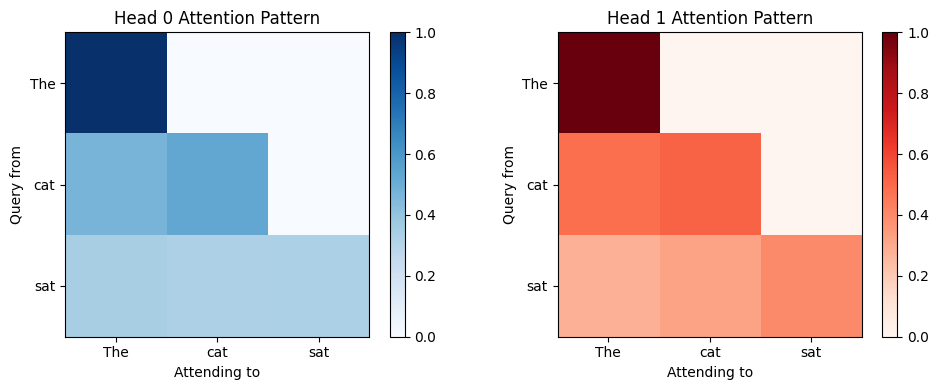

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize attention patterns for both heads
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Get attention weights for visualization
with torch.no_grad():
    # Run through the actual forward pass
    output = mha(x)

    # Manually compute attention weights for visualization
    q = mha.W_query(x).view(1, 3, 2, 2).transpose(1, 2)
    k = mha.W_key(x).view(1, 3, 2, 2).transpose(1, 2)
    scores = torch.matmul(q, k.transpose(-2, -1))
    scores[:, :, mask] = float('-inf')
    weights = F.softmax(scores / (2**0.5), dim=-1)

tokens = ['The', 'cat', 'sat']

# Plot Head 0
im1 = ax1.imshow(weights[0, 0].numpy(), cmap='Blues', vmin=0, vmax=1)
ax1.set_xticks(range(3))
ax1.set_yticks(range(3))
ax1.set_xticklabels(tokens)
ax1.set_yticklabels(tokens)
ax1.set_xlabel('Attending to')
ax1.set_ylabel('Query from')
ax1.set_title('Head 0 Attention Pattern')

# Plot Head 1
im2 = ax2.imshow(weights[0, 1].numpy(), cmap='Reds', vmin=0, vmax=1)
ax2.set_xticks(range(3))
ax2.set_yticks(range(3))
ax2.set_xticklabels(tokens)
ax2.set_yticklabels(tokens)
ax2.set_xlabel('Attending to')
ax2.set_ylabel('Query from')
ax2.set_title('Head 1 Attention Pattern')

# Add colorbars
plt.colorbar(im1, ax=ax1, fraction=0.046)
plt.colorbar(im2, ax=ax2, fraction=0.046)

plt.tight_layout()
plt.show()

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 512, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

In [ ]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = data_loader(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = data_loader(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [ ]:
def generate_text(model, idx, max_new_tokens, context_size, temperature=1.0):
    """
    Generate text token-by-token using an autoregressive language model.
    """
    for _ in range(max_new_tokens):
        # Use only the most recent context
        idx_cond = idx[:, -context_size:]

        # Get model predictions
        with torch.no_grad():
            logits = model(idx_cond)[:, -1, :]  # Get logits for the last token

        # Apply temperature scaling
        logits /= temperature

        # Convert logits to probabilities and sample the next token
        probs = torch.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)  # Sample from the probability distribution

        # Append the sampled token to the sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx


In [ ]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "It is recommended to take rest when"
tokenizer = tiktoken.get_encoding("cl100k_base")

token_ids = generate_text(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)



In [ ]:
print("Untrained Model Says This :\n", token_ids_to_text(token_ids, tokenizer))

Untrained Model Says This :
 It is recommended to take rest wheniable.child(cellazine Ges701 Killed地址.pk Kaz


In [ ]:
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

In [ ]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 37888
Validation tokens: 4096
All tokens: 41984


In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
    """
     Computes the loss for a single batch of input and target data.
    :param input_batch:
    :param target_batch:
    :param model:
    :param device:
    :return:
    """
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [ ]:
model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes
torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.95403003692627
Validation loss: 10.938669204711914


In [ ]:
def train_model(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [ ]:

import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 100
train_losses, val_losses, tokens_seen = train_model(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="patient has high", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.434, Val loss 9.423
Ep 1 (Step 000005): Train loss 8.088, Val loss 7.886
Ep 1 (Step 000010): Train loss 6.910, Val loss 6.818
Ep 1 (Step 000015): Train loss 6.666, Val loss 6.360
Ep 1 (Step 000020): Train loss 6.399, Val loss 6.169
Ep 1 (Step 000025): Train loss 6.025, Val loss 6.002
Ep 1 (Step 000030): Train loss 6.027, Val loss 5.905
Ep 1 (Step 000035): Train loss 5.657, Val loss 5.811
 missions: Sime diff =   .modelsERRORion="#"> pictureMeta   ",ime[$ak    ig, publicda.copy mysqli O -imeign
Ep 2 (Step 000040): Train loss 5.779, Val loss 5.558
Ep 2 (Step 000045): Train loss 5.335, Val loss 5.199
Ep 2 (Step 000050): Train loss 4.781, Val loss 5.023
Ep 2 (Step 000055): Train loss 4.861, Val loss 4.879
Ep 2 (Step 000060): Train loss 4.362, Val loss 4.688
Ep 2 (Step 000065): Train loss 4.319, Val loss 4.617
Ep 2 (Step 000070): Train loss 4.195, Val loss 4.460
 . Symfony  -ery learn.  X-task Animation
Ep 3 (Step 000075): Train loss 4.043, Val loss 4.381
Ep

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
torch.save(model.state_dict(),"/content/drive/MyDrive/Robust_Medical_LLM_Dataset/models/gpt_model_124M.pth")

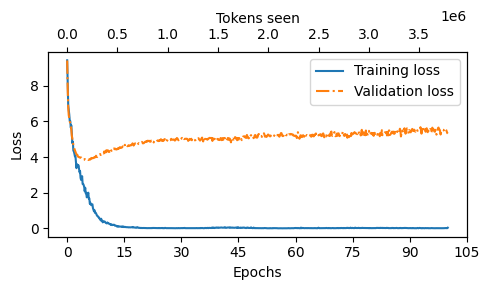

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [ ]:
model.to("cpu")
model.eval()
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text(
    model=model,
    idx=text_to_token_ids("We will continue his home exercise", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 We will continue his home exercise for chronic problems.

PLAN

Respiratory: Ecchymosis over the lateral malleolus


In [ ]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

**Top-k and Temperature**

 **Top-k** limits the model's choice to the *k* most probable next words, discarding less likely options. **Temperature** scales the probability distribution; higher values increase randomness by making the distribution more uniform, while lower values favor the most likely word by making it more peaked.  For instance, when creating a poem, high temperature with low Top-k might yield unusual word choices. Conversely, low temperature with high Top-k would produce a more predictable, coherent verse.  In essence, they dictate how "focused" versus "creative" the generated text becomes.

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("the pain in the", tokenizer),
    max_new_tokens=150,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.2
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 the pain in the patient have a right foot a right foot not doing well with subchondral marrow edema and cyst formation.

ASSESSMENT

• Right hip degenerative joint disease.

PLAN

I discussed the clinical and rad limited to continued pain. At this time, use. The patient who is in agreement. We will increase metforminopathy.

 CC: We will a wide local excision with a 1-2 stress level is


I provided paper prescription refills for Cialis and the procedure in detail, including the lab of the injection related to the truck into the questions or concerns. If hallux rigidus.


Patient Agreements:
INSTRUCTIONS



In [ ]:
def capture_and_plot_attention(model, text, tokenizer, layer_idx=0, device='cpu'):
    """Simple function to capture and visualize attention from your existing model"""
    model.eval()

    # Tokenize input
    input_ids = text_to_token_ids(text, tokenizer).to(device)
    tokens = tokenizer.decode(input_ids[0].tolist()).split()

    # Storage for attention weights
    attention_weights = []

    # Hook function to capture attention
    def attention_hook(module, input, output):
        x = input[0]
        b, num_tokens, d_in = x.shape

        with torch.no_grad():
            # Calculate queries, keys
            queries = module.W_query(x)
            keys = module.W_key(x)

            # Reshape for multi-head attention
            queries = queries.view(b, num_tokens, module.num_heads, module.head_dim).transpose(1, 2)
            keys = keys.view(b, num_tokens, module.num_heads, module.head_dim).transpose(1, 2)

            # Calculate attention scores
            scores = queries @ keys.transpose(2, 3)

            # Apply causal mask
            mask = module.mask.bool()[:num_tokens, :num_tokens]
            scores = scores.masked_fill(mask, float('-inf'))

            # Get attention weights
            weights = torch.softmax(scores / (module.head_dim ** 0.5), dim=-1)
            attention_weights.append(weights.cpu())

    # Register hook on the desired layer
    hook = model.trf_blocks[layer_idx].att.register_forward_hook(attention_hook)

    # Forward pass
    with torch.no_grad():
        _ = model(input_ids)

    # Remove hook
    hook.remove()

    # Plot attention for each head
    attn = attention_weights[0][0]  # First batch
    n_heads = attn.shape[0]

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for head in range(min(n_heads, 12)):
        ax = axes[head]
        im = ax.imshow(attn[head].numpy(), cmap='Blues', aspect='auto')

        # Set labels
        ax.set_xticks(range(len(tokens)))
        ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(tokens)))
        ax.set_yticklabels(tokens, fontsize=8)
        ax.set_title(f'Head {head}')

        # Add colorbar
        plt.colorbar(im, ax=ax, fraction=0.046)

    # Hide extra subplots
    for idx in range(n_heads, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Attention Patterns - Layer {layer_idx}', fontsize=16)
    plt.tight_layout()
    plt.show()

    return attention_weights

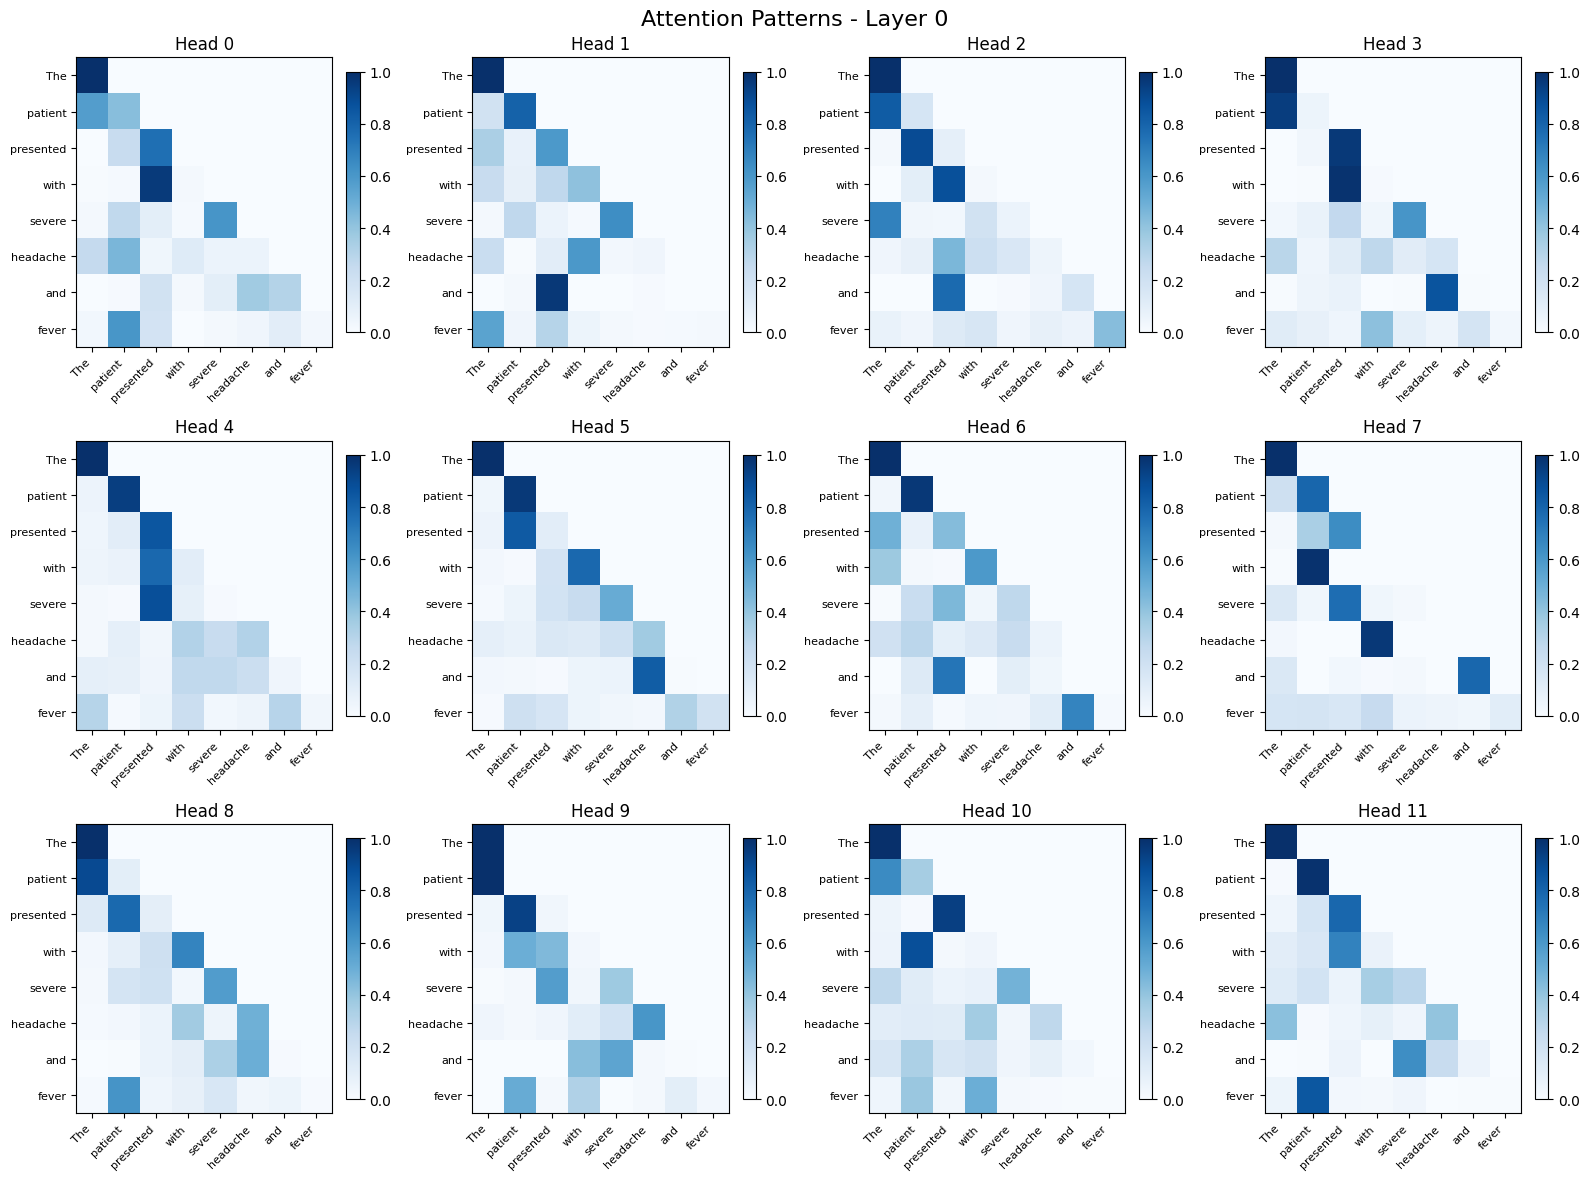

In [ ]:
medical_text = "The patient presented with severe headache and fever"
attention = capture_and_plot_attention(model, medical_text, tokenizer, layer_idx=0)

In [ ]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(512, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

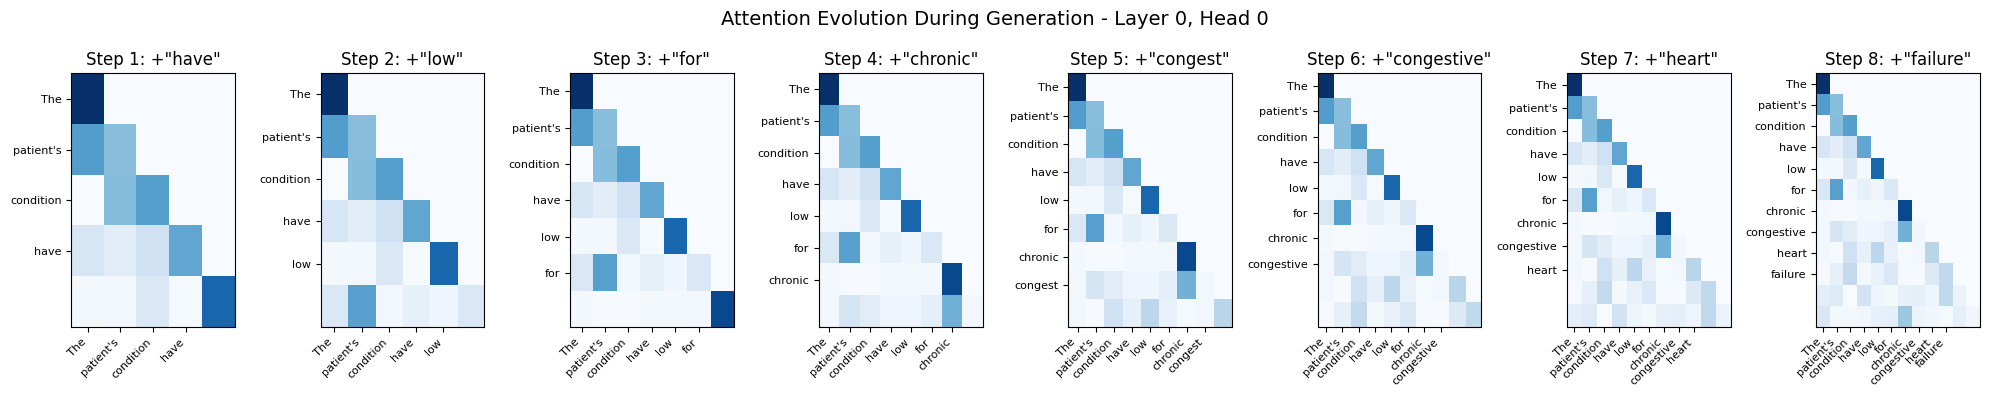


Generated: The patient's condition have low for chronic congestive heart failure


In [ ]:
def visualize_generation_step_by_step(model, start_text, tokenizer, n_steps=5, layer_idx=0):
    """Visualize attention at each generation step"""
    input_ids = text_to_token_ids(start_text, tokenizer)
    context_size = model.pos_emb.weight.shape[0]

    fig, axes = plt.subplots(1, n_steps, figsize=(20, 4))

    for step in range(n_steps):
        # Generate one token
        with torch.no_grad():
            idx_cond = input_ids[:, -context_size:]
            logits = model(idx_cond)[:, -1, :]
            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            input_ids = torch.cat([input_ids, next_token], dim=1)

        # Capture attention for current sequence
        current_text = tokenizer.decode(input_ids[0].tolist())
        tokens = current_text.split()

        # Get attention using hook
        attn_weights = []
        def hook(module, input, output):
            x = input[0]
            b, n_tok, d = x.shape
            q = module.W_query(x).view(b, n_tok, module.num_heads, module.head_dim).transpose(1, 2)
            k = module.W_key(x).view(b, n_tok, module.num_heads, module.head_dim).transpose(1, 2)
            scores = q @ k.transpose(2, 3)
            mask = module.mask.bool()[:n_tok, :n_tok]
            scores = scores.masked_fill(mask, float('-inf'))
            weights = torch.softmax(scores / (module.head_dim ** 0.5), dim=-1)
            attn_weights.append(weights.cpu())

        handle = model.trf_blocks[layer_idx].att.register_forward_hook(hook)
        with torch.no_grad():
            _ = model(input_ids[:, -context_size:])
        handle.remove()

        # Plot attention for head 0
        ax = axes[step]
        attn = attn_weights[0][0, 0].numpy()  # First head
        im = ax.imshow(attn, cmap='Blues', aspect='auto')

        # Labels
        ax.set_xticks(range(len(tokens)))
        ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(tokens)))
        ax.set_yticklabels(tokens, fontsize=8)
        ax.set_title(f'Step {step+1}: +"{tokens[-1]}"')

    plt.suptitle(f'Attention Evolution During Generation - Layer {layer_idx}, Head 0', fontsize=14)
    plt.tight_layout()
    plt.show()

    return tokenizer.decode(input_ids[0].tolist())

# Visualize generation process
generated_text = visualize_generation_step_by_step(
    model, "The patient's condition", tokenizer, n_steps=8, layer_idx=0
)
print(f"\nGenerated: {generated_text}")